# Principal Component Analysis (PCA)

**Principal Component Analysis (PCA)** is a dimensionality reduction technique used to **reduce the number of features in a dataset while preserving as much important information as possible**.

PCA transforms the original features into a new set of features called **Principal Components**.

### Key Ideas

- **Principal Components** are new features created from the original features.
- The first principal component captures the **maximum variance** in the data.
- The second principal component captures the next highest variance and is uncorrelated with the first.
- Each subsequent component captures the remaining maximum possible variance.
- PCA can reduce the complexity of high-dimensional datasets.

### Example

Suppose we have a dataset with 10 features:

$$
10\ Features \rightarrow PCA \rightarrow 2\ Principal\ Components
$$

The 2 principal components can represent most of the important information from the original 10 features.

### Steps of PCA

1. **Standardize the data**
2. **Calculate the covariance matrix**
3. **Calculate eigenvalues and eigenvectors**
4. **Select the principal components**
5. **Transform the original data**

### Why Use PCA?

- Reduce the number of features
- Reduce computational complexity
- Remove feature redundancy
- Help visualize high-dimensional data
- Improve model training efficiency

### In Simple Words

> **PCA finds the most important directions of variation in the data and uses them as new features.**

PCA is an **unsupervised dimensionality reduction technique** because it does not require a target variable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_data(n, M = 2.0, B = 5.0, X_MIN = 0.0, X_MAX = 30.0):
      
      n_samples = n
      random = np.random.RandomState(1)  # RandomState Seeding

      # create random x values
      x1 = random.uniform(low=X_MIN, high=X_MAX, size=n_samples).reshape(n_samples, 1) 

      # calculate x2 values along the line
      x2 = M * x1 + B

      # add random noise
      x2 += random.normal(loc=0.0, scale=5.0, size=x2.shape).reshape(n_samples, 1)
      X = np.concatenate([np.round(x1,2), np.round(x2,2)], axis=1)
      return X 

X = generate_data(25)

# Normalize
X[:,0] = (X[:,0] - X[:,0].mean()) / X[:,0].std()
X[:,1] = (X[:,1] - X[:,1].mean()) / X[:,1].std()

X.shape

(25, 2)

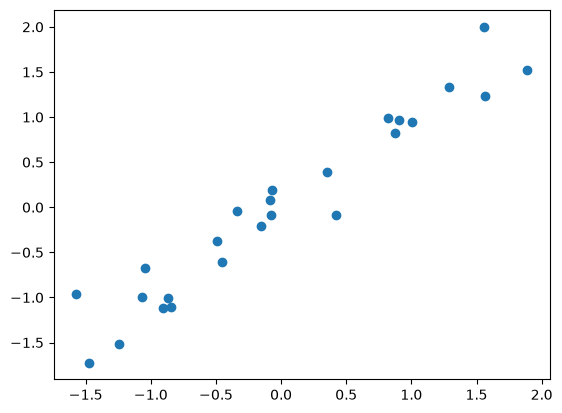

In [3]:
plt.scatter(X[:,0], X[:,1])

# Covariance Matrix

A **Covariance Matrix** is a matrix that shows the **covariance between multiple variables** in a dataset.

It helps us understand how different features **change together**.

### Example

Suppose we have three features:

- **Height**
- **Weight**
- **Age**

The covariance matrix might look like:

$$
\begin{bmatrix}
Cov(Height,Height) & Cov(Height,Weight) & Cov(Height,Age) \\
Cov(Weight,Height) & Cov(Weight,Weight) & Cov(Weight,Age) \\
Cov(Age,Height) & Cov(Age,Weight) & Cov(Age,Age)
\end{bmatrix}
$$

### Important Points

- The **diagonal values** represent the variance of each feature.
- The values **above and below the diagonal are the same**.
- A **positive value** means two features tend to increase together.
- A **negative value** means one feature tends to increase while the other decreases.
- A value close to **zero** indicates little or no linear relationship.

### Example Covariance Matrix

$$
\begin{bmatrix}
4 & 2 & -1 \\
2 & 9 & 3 \\
-1 & 3 & 16
\end{bmatrix}
$$

Here:

- `4` = Variance of Feature 1
- `9` = Variance of Feature 2
- `16` = Variance of Feature 3
- `2` = Positive covariance between Feature 1 and Feature 2
- `-1` = Negative covariance between Feature 1 and Feature 3
- `3` = Positive covariance between Feature 2 and Feature 3

### Covariance Matrix in PCA

The **covariance matrix is an important step in PCA**.

PCA uses the covariance matrix to understand the relationships between features and find the directions of **maximum variance**.

### In Simple Words

> **A covariance matrix shows how every pair of features in a dataset changes together.**

In [4]:
cov = np.dot(X.T, X)
cov

array([[25.        , 24.12294297],
       [24.12294297, 25.        ]])

In [5]:
e_values, e_vectors = np.linalg.eig(cov)

In [6]:
e_values

array([ 0.87705703+0.j, 49.12294297+0.j])

In [7]:
e_vectors

array([[-0.70710678+0.j, -0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

In [9]:
v1, v2 = e_vectors[:,0], e_vectors[:, 1]

In [12]:
v1 ,v2

(array([-0.70710678+0.j,  0.70710678+0.j]),
 array([-0.70710678+0.j, -0.70710678+0.j]))

In [18]:
idx = e_values.argsort()[::-1]
e_values = e_values[idx]

principle_component = e_vectors[:, idx]


In [19]:
principle_component

array([[-0.70710678+0.j, -0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

In [20]:
no_of_pc  = principle_component.shape[1]
explained_variance = []

for i in range(no_of_pc):
    variance = (e_values[i] / sum(np.diagonal(cov)) * 100)
    explained_variance.append(variance)
    
explained_variance
    

[np.complex128(98.24588594597589+0j), np.complex128(1.754114054024121+0j)]

In [25]:
#Projecting the data into the principle components
U = principle_component[:,0]


In [26]:
X_projected = np.dot(U.T, X.T).T

In [27]:
X_projected

array([ 0.11610056+0.j, -0.03683979+0.j,  0.43251569+0.j,  0.08419847+0.j,
        0.26301084+0.j, -0.19542248+0.j, -0.14631016+0.j,  0.20882917+0.j,
       -0.03489501+0.j,  0.02973083+0.j,  0.18472305+0.j, -0.03797148+0.j,
       -0.18569292+0.j, -0.2365879 +0.j, -0.17530215+0.j,  0.12006461+0.j,
       -0.00527607+0.j, -0.35839186+0.j,  0.05179363+0.j, -0.10046113+0.j,
        0.03133794+0.j, -0.26127979+0.j, -0.10770723+0.j,  0.04654736+0.j,
        0.31328585+0.j])